# Crop Disease Detection using Machine Learning - Phase 1 - EDA

- **Dataset:** crop_disease_dataset.csv
- **Rows:** 5,000 | **Columns:** 18 (17 features + 1 target)
- **Target Variable:** disease_label -> **Healthy** / **Fungal** / **Bacterial** / **Pest Damage**


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,5)


## 2. Load Dataset & Initial Inspection

##### We start by loading the dataset and reviewing its shape, column names, data types, and a sample of rows.

In [2]:
cropdis= pd.read_csv('crop_disease_dataset.csv')
print("\nShape:", cropdis.shape)
cropdis.head(10)


Shape: (5000, 18)


,crop_type,region,season,soil_type,irrigation_method,temperature_C,humidity_percent,rainfall_mm,leaf_wetness_hrs,soil_pH,nitrogen_kg_ha,phosphorus_kg_ha,potassium_kg_ha,days_since_last_rain,plant_age_days,pesticide_applied,fertilizer_kg_ha,disease_label
0,maize,NaN,Kharif,Clay,FLOOD,26.209077,NaN,101.582271,14.009117,7.085974,39.893186,58.936746,44.894035,NaN,22.0,0.0,53.719785,Fungal
1,Cotton,Central,Rabi,NaN,Sprinkler,33.430687,58.979548,30.296413,11.067606,6.190607,179.824571,88.881893,71.394673,8.0,13.0,0.0,92.819906,Pest Damage
2,cotton,NaN,NaN,CLAY,Drip,28.047989,62.103653,90.564280,21.470657,6.224184,89.690594,17.839237,55.877176,5.0,31.0,0.0,68.282729,Bacterial
3,Soybean,North,Rabi,NaN,NaN,31.411229,54.430551,16.922677,19.309367,6.925993,143.060345,62.503022,91.410148,49.0,116.0,0.0,62.743722,Bacterial
4,cotton,NaN,kharif,sandy,FLOOD,22.822997,56.975619,NaN,12.402934,NaN,134.998574,80.448392,57.815445,29.0,84.0,0.0,84.100232,Healthy
5,Rice,NaN,RABI,Sandy,NaN,24.888346,NaN,8.542214,6.491779,7.739443,141.350185,27.491768,97.519647,NaN,46.0,1.0,NaN,Healthy
6,Wheat,SOUTH,NaN,Loamy,drip,22.967913,71.242234,25.450444,3.534706,7.300042,95.465953,71.889419,81.389186,41.0,23.0,1.0,43.297961,Healthy
7,WHEAT,East,Kharif,CLAY,drip,36.706309,62.994202,1.644086,13.264937,6.946764,109.830941,66.507958,62.003946,NaN,115.0,1.0,28.177089,Pest Damage
8,Rice,NaN,Zaid,NaN,NaN,32.950571,52.223510,60.894481,7.104720,4.894959,131.951121,17.402525,47.933432,12.0,19.0,1.0,39.365462,Bacterial
9,cotton,north,Kharif,loamy,NaN,27.157029,58.829844,62.547348,6.341179,7.383311,120.118510,81.937478,94.299452,0.0,33.0,1.0,40.838405,Bacterial


In [3]:
cropdis.info()            # Column Data Types and Not-Null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   crop_type             5000 non-null   object 
 1   region                3943 non-null   object 
 2   season                3595 non-null   object 
 3   soil_type             3875 non-null   object 
 4   irrigation_method     3785 non-null   object 
 5   temperature_C         4750 non-null   float64
 6   humidity_percent      4800 non-null   float64
 7   rainfall_mm           4750 non-null   float64
 8   leaf_wetness_hrs      4850 non-null   float64
 9   soil_pH               4802 non-null   float64
 10  nitrogen_kg_ha        4800 non-null   float64
 11  phosphorus_kg_ha      4850 non-null   float64
 12  potassium_kg_ha       4850 non-null   float64
 13  days_since_last_rain  4800 non-null   float64
 14  plant_age_days        4850 non-null   float64
 15  pesticide_applied    

#### Observations: 

 - The Dataset has 5,000 rows and 18 Columns - 17 Features + 1 Target (disease_label)
 - **5 Categorical Columns** (object dtype), **12 numerical** (float64), **1 binary** (pesticide_applied)
 - Target variable disease_label has no missing values
 - Already visible from head(): inconsistent capitalisation ('South','south','SOUTH') and NaN values in region, season etc columns

In [4]:
cropdis.describe()    # Statistical Summary of Numerical Columns

,temperature_C,humidity_percent,rainfall_mm,leaf_wetness_hrs,soil_pH,nitrogen_kg_ha,phosphorus_kg_ha,potassium_kg_ha,days_since_last_rain,plant_age_days,pesticide_applied,fertilizer_kg_ha
count,4750.000000,4800.000000,4750.000000,4850.000000,4802.000000,4800.000000,4850.000000,4850.000000,4800.000000,4850.000000,4970.000000,4800.000000
mean,29.694055,66.520511,42.302889,12.025019,6.491353,120.119532,60.274004,80.321646,29.291667,64.260825,0.595372,51.014820
std,7.385366,14.397293,66.200241,6.914420,1.092348,29.990148,20.171449,24.964939,17.219660,31.790071,0.490869,27.094815
min,-5.000000,-10.000000,-1.000000,0.003629,-1.000000,-13.889056,-8.539660,-5.543643,0.000000,10.000000,0.000000,-19.151555
25%,25.701964,57.097872,11.435357,6.043166,5.805450,100.409665,47.066330,63.256816,14.000000,37.000000,0.000000,36.975049
50%,29.088057,65.812531,27.927325,12.090766,6.482679,120.004664,60.160683,80.188018,29.000000,64.000000,1.000000,50.440463
75%,33.249688,75.700110,56.273303,17.984177,7.180808,140.152395,73.589906,97.230313,44.000000,92.000000,1.000000,63.616207
max,120.000000,200.000000,999.000000,23.995631,15.000000,232.804657,128.774184,158.793804,59.000000,119.000000,1.000000,500.000000


## 3. Duplicate Record Analysis
##### We identify does the dataset has any duplicate records or not

In [5]:
print("Duplicate Records:", cropdis.duplicated().sum())
if(cropdis.duplicated().sum() == 0):
    print("No duplicated records exists in the dataset")
else:
    print("Duplicated Records:", cropdis.duplicated().sum())

Duplicate Records: 0
No duplicated records exists in the dataset


## 4. Missing Value Analysis

##### We identify which columns have missing values and what percentage of data is lost

In [6]:
cropdis.isnull().sum()     # Count of missing values per column

crop_type                  0
region                  1057
season                  1405
soil_type               1125
irrigation_method       1215
temperature_C            250
humidity_percent         200
rainfall_mm              250
leaf_wetness_hrs         150
soil_pH                  198
nitrogen_kg_ha           200
phosphorus_kg_ha         150
potassium_kg_ha          150
days_since_last_rain     200
plant_age_days           150
pesticide_applied         30
fertilizer_kg_ha         200
disease_label              0
dtype: int64

In [7]:
missing = cropdis.isnull().sum().sort_values(ascending = False)
missing_pct = (missing/len(cropdis) *100).round(2)
missing_df= pd.DataFrame({"Missing Count" : missing, "Missing %" : missing_pct})
missing_df[missing_df["Missing Count"]>0]

,Missing Count,Missing %
season,1405,28.10
irrigation_method,1215,24.30
soil_type,1125,22.50
region,1057,21.14
rainfall_mm,250,5.00
temperature_C,250,5.00
fertilizer_kg_ha,200,4.00
humidity_percent,200,4.00
days_since_last_rain,200,4.00
nitrogen_kg_ha,200,4.00


#### Observations:
- **Categorical Columns** have the highest missing rates: `season` (28.10 %), `irrigation_method` (24.30 %), `soli_type` (22.50 %), `region` (21.14 %)
- **Numercial Columns** have 3-5 % missing - relatively manageable. Imputation strategy (Mean vs Median) will be decided based on skewness.
- `pesticide_applied` has only 30 missing values (0.60%) - minimal impact
- `crop_type` and `disease_label` has no missing values - no action needed

## 5. Categorical Column Inspection - Inconsistent Capitalisation
The Problem statement warns that categorical column contains inconsistent capitalisation.
We list all Unique raw values per column to identify the issue.

In [8]:
cat_cols = ['crop_type','region','season','soil_type','irrigation_method','disease_label']
for col in cat_cols:
    val = cropdis[col].dropna().unique().tolist()
    print(col,":","  ",val)

crop_type :    ['maize', 'Cotton', 'cotton', 'Soybean', 'Rice', 'Wheat', 'WHEAT', 'Maize', 'rice']
region :    ['Central', 'North', 'SOUTH', 'East', 'north', 'South', 'West']
season :    ['Kharif', 'Rabi', 'kharif', 'RABI', 'Zaid']
soil_type :    ['Clay', 'CLAY', 'sandy', 'Sandy', 'Loamy', 'loamy', 'Silty']
irrigation_method :    ['FLOOD', 'Sprinkler', 'Drip', 'drip', 'Rainfed', 'Flood']
disease_label :    ['Fungal', 'Pest Damage', 'Bacterial', 'Healthy']


#### Observations:
- Same crop in 3 different cases, mixed case for same regions, same seasons in different cases in almost all columns.
- `disease_label` column is formatted correctly
- **Fix needed:** Standardising all categorical columns to TITILE CASE

## 6. Target Variable - Class Distribution

We check how balanced the four disease classes are.

In [9]:
label_count = cropdis["disease_label"].value_counts()
percentage = (label_count / len(cropdis) * 100).round(2)
print(pd.DataFrame({"Count:" : label_count,"Percentage %" : percentage}))

               Count:  Percentage %
disease_label                      
Healthy          1531         30.62
Bacterial        1253         25.06
Fungal           1217         24.34
Pest Damage       999         19.98


#### Observations:

- **Healthy:** 1,531 (30.6 %) - Large Class
- **Bacterial:** 1,253 (25.1 %)
- **Fungal:** 1,217 (24.3 %)
- **Pest Damage:** 999 (20 %)

## 7. Numerical Columns: Mean, Median & Skewness
We compute Mean, Median and Skewness for numerical column. **This tells us upfront which column are symmetric and which are skewed** - skewed columns are where outliers are most likely to be distorting the distribution. 

In [10]:
num_cols = ['temperature_C', 'humidity_percent', 'rainfall_mm', 'leaf_wetness_hrs', 'soil_pH', 'nitrogen_kg_ha', 'phosphorus_kg_ha', 'potassium_kg_ha', 'days_since_last_rain', 'plant_age_days', 'fertilizer_kg_ha']
stats = pd.DataFrame({'Mean' : cropdis[num_cols].mean(), 'Median' : cropdis[num_cols].median(), 'Skewness' : cropdis[num_cols].skew()}).round(3)
stats['Mean - Median Gap'] = (stats['Mean']-stats['Median']).round(3)
stats=stats.sort_values('Skewness',key = abs, ascending = False)
stats

,Mean,Median,Skewness,Mean - Median Gap
rainfall_mm,42.303,27.927,9.873,14.376
fertilizer_kg_ha,51.015,50.440,7.513,0.575
temperature_C,29.694,29.088,5.377,0.606
humidity_percent,66.521,65.813,1.008,0.708
soil_pH,6.491,6.483,0.163,0.008
potassium_kg_ha,80.322,80.188,0.024,0.134
plant_age_days,64.261,64.000,0.017,0.261
nitrogen_kg_ha,120.120,120.005,-0.016,0.115
days_since_last_rain,29.292,29.000,0.014,0.292
leaf_wetness_hrs,12.025,12.091,-0.013,-0.066


#### Observations:
- `rainfall_mm` has the highest skewness (~ 9.9) and the largest mean-median gap (~ 14.4) — a strong sign of extreme high-end outliers pulling the mean up.
- `fertilizer_kg_ha` and `temperature_C` are also heavily skewed (e.g temperature above 55°C, negative fertilizers)
- `humidity_percent` shows mild skew (~1.0) - boarderline
- All remaining columns — `leaf_wetness_hrs`, `soil_pH`, `nitrogen_kg_ha`, `phosphorus_kg_ha`, `potassium_kg_ha`, `days_since_last_rain`, `plant_age_days` — have skewness very close to 0 and a negligible mean-median gap, meaning they are roughly symmetric with no major outlier distortion visible at the aggregate level.

**Decision:** Based on this table, we'll plot histograms only for the columns where skew signals a real outlier problem — `temperature_C`, `humidity_percent`, `rainfall_mm`, and `fertilizer_kg_ha`.

## 8. Numerical Feature Distribution & Implausible Outliers

Based on the skewness table above, we plot histograms for the four columns that showed meaningful skew — `temperature_C`, `humidity_percent`, `rainfall_mm`, and `fertilizer_kg_ha`

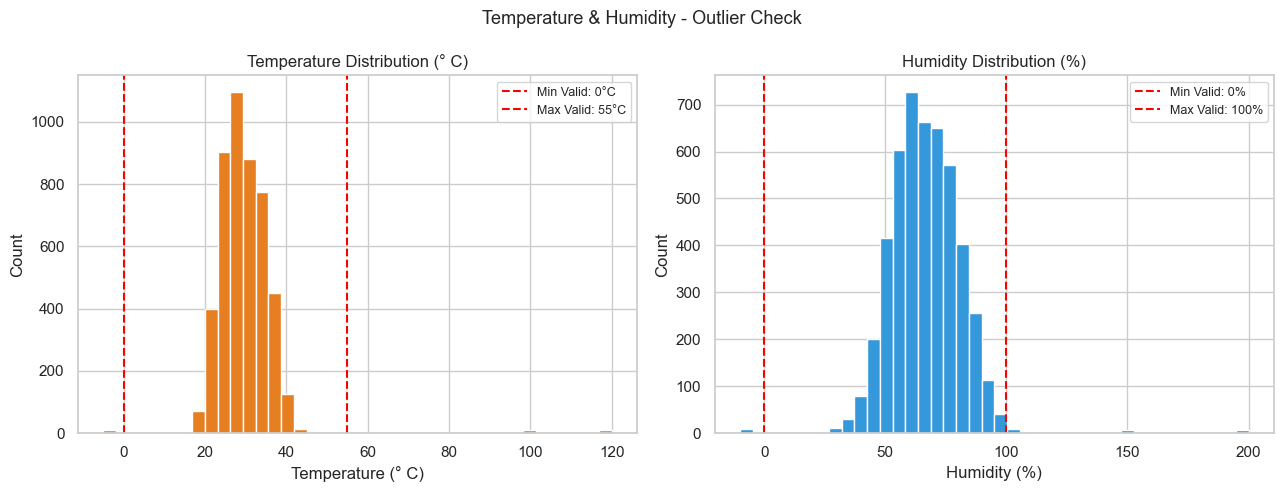

In [11]:
# Temperature and Humidity

fig, axes = plt.subplots(1,2, figsize=(13,5))

axes[0].hist(cropdis["temperature_C"].dropna(), bins = 40, color = '#e67e22', edgecolor = 'white')
axes[0].axvline(0,color= 'red', linestyle = '--', linewidth=1.5, label = 'Min Valid: 0°C')
axes[0].axvline(55,color = 'red', linestyle = '--', linewidth = 1.5, label = 'Max Valid: 55°C')
axes[0].set_title("Temperature Distribution (° C)")
axes[0].set_xlabel("Temperature (° C)")
axes[0].set_ylabel("Count")
axes[0].legend (fontsize = 9)

axes[1].hist(cropdis["humidity_percent"].dropna(),bins = 40, color = "#3498db", edgecolor = "white")
axes[1].axvline(0, color='red', linestyle ='--', linewidth = 1.5, label ='Min Valid: 0%')
axes[1].axvline(100,color='red', linestyle = '--', linewidth = 1.5, label = 'Max Valid: 100%')
axes[1].set_title('Humidity Distribution (%)')
axes[1].set_xlabel('Humidity (%)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize =9)

plt.suptitle("Temperature & Humidity - Outlier Check", fontsize = 13)
plt.tight_layout()
plt.show()

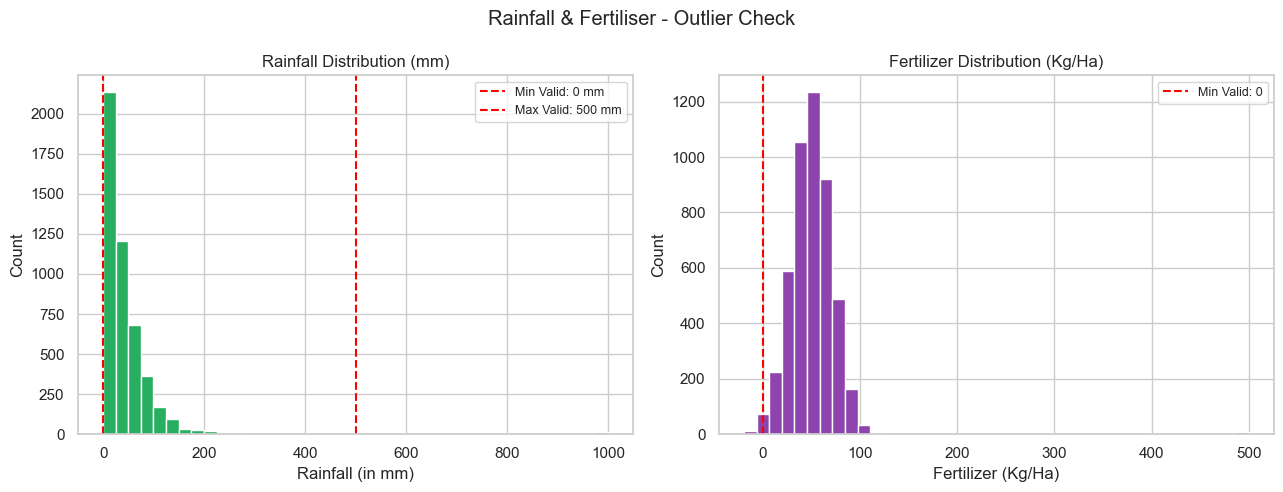

In [12]:
# Rainfall & Fertilizer

fig, axes = plt.subplots(1,2,figsize=(13,5))

axes[0].hist(cropdis['rainfall_mm'].dropna(),bins = 40, color = '#27ae60', edgecolor = 'white')
axes[0].axvline(0,color='red', linestyle = '--', linewidth = 1.5, label = 'Min Valid: 0 mm')
axes[0].axvline(500, color='red', linestyle='--', linewidth = 1.5, label = 'Max Valid: 500 mm')
axes[0].set_title('Rainfall Distribution (mm)')
axes[0].set_xlabel('Rainfall (in mm)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize =9)

axes[1].hist(cropdis["fertilizer_kg_ha"].dropna(),bins=40, color = '#8e44ad', edgecolor='white')
axes[1].axvline(0, color ='red', linestyle = '--', linewidth=1.5, label = 'Min Valid: 0')
axes[1].set_title("Fertilizer Distribution (Kg/Ha)")
axes[1].set_xlabel("Fertilizer (Kg/Ha)")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=9)

plt.suptitle("Rainfall & Fertiliser - Outlier Check")
plt.tight_layout()
plt.show()

## 9. Soil pH by Disease Class - Boxplot

We examine whether soil pH shows any pattern across Disease Categories

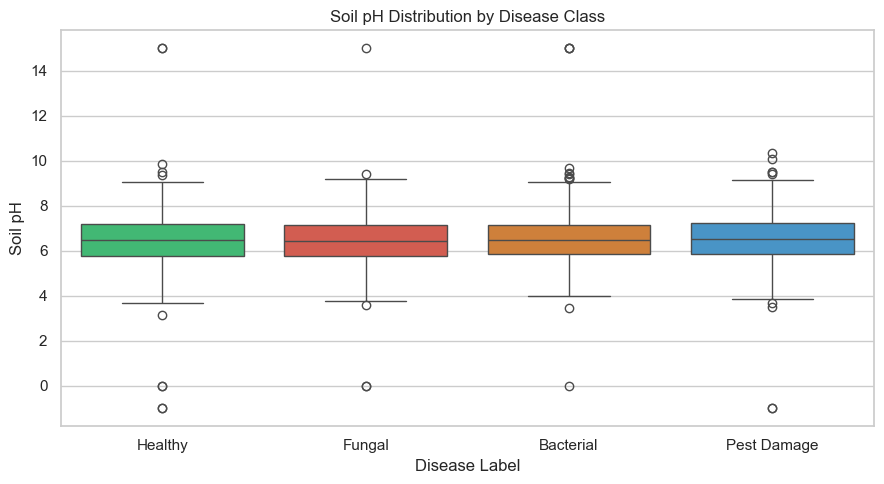

Median pH by Disease_Label:
disease_label
Bacterial      6.496
Fungal         6.454
Healthy        6.470
Pest Damage    6.522
Name: soil_pH, dtype: float64


In [26]:
fig,ax = plt.subplots(figsize=(9,5,))
order_box= ['Healthy','Fungal','Bacterial','Pest Damage']
palette = {'Healthy':'#2ecc71','Fungal':'#e74c3c','Bacterial':'#e67e22','Pest Damage':'#3498db'}
sns.boxplot(x='disease_label', y='soil_pH',data=cropdis, order=order_box, hue='disease_label', palette=palette,
            legend=False, ax=ax)
ax.set_title("Soil pH Distribution by Disease Class")
ax.set_xlabel("Disease Label")
ax.set_ylabel("Soil pH")
plt.tight_layout()
plt.show()

# Print median pH per class

print("Median pH by Disease_Label:")
print(cropdis.groupby('disease_label') ['soil_pH'].median().round(3))


#### Observations:

- **The median soil pH** is similar across all disease classes **(around 6.4–6.6)**, indicating that soil pH alone may not strongly differentiate disease types.
- A few observations lie outside the valid pH range (greater than 10), suggesting the presence of implausible values that should be treated during data cleaning.
- The Fungal and Bacterial classes show slightly greater variability in soil pH than the Healthy class, although the overlap between groups remains substantial.
- Overall, soil pH appears to have some influence but is unlikely to be the primary predictor of disease. Other environmental variables such as temperature, humidity
and rainfall may contribute more to disease classification.

## 10. Correlation Heatmap - Numerical Features

We compute pairwise correlations to identify multicolinearity and any strong relationships between features

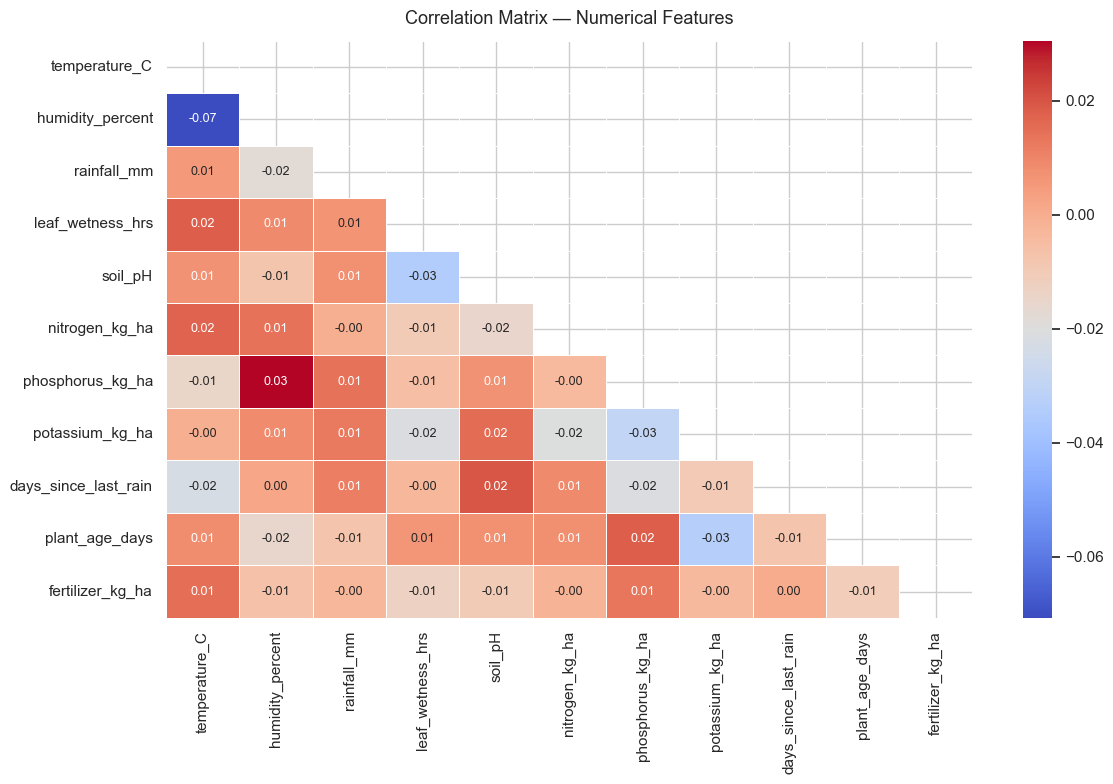

In [47]:
num_cols = ['temperature_C', 'humidity_percent', 'rainfall_mm', 'leaf_wetness_hrs',
            'soil_pH', 'nitrogen_kg_ha', 'phosphorus_kg_ha', 'potassium_kg_ha',
            'days_since_last_rain', 'plant_age_days', 'fertilizer_kg_ha']

corr = cropdis[num_cols].corr()

fig,ax=plt.subplots(figsize=(12,8))
mask = np.triu(np.ones_like(corr, dtype=bool))   # np.triu() returns the upper triangular portion of the matrix, so that duplicate information is hidden
sns.heatmap(corr, annot=True, fmt='.2f',cmap='coolwarm', mask=mask, linewidth = 0.5, ax=ax, annot_kws = {'size':9})

ax.set_title('Correlation Matrix — Numerical Features', fontsize=13, pad=12)
plt.tight_layout()
plt.show()


### Observations
- Most numerical features show very weak correlations (close to 0), indicating minimal linear relationships.
- The highest correlation (~0.03 between humidity_percent and phosphorus_kg_ha) is negligible.
- **No significant multicollinearity is observed, so all numerical features can be retained for modeling.**
- The weak correlations suggest that combining multiple features may help the model identify better patterns.

## 11. Key Feature Distributions by Disease Class

We plot box plots for the most domain relevant numeric features grouped by disease class to check for discriminating patterns


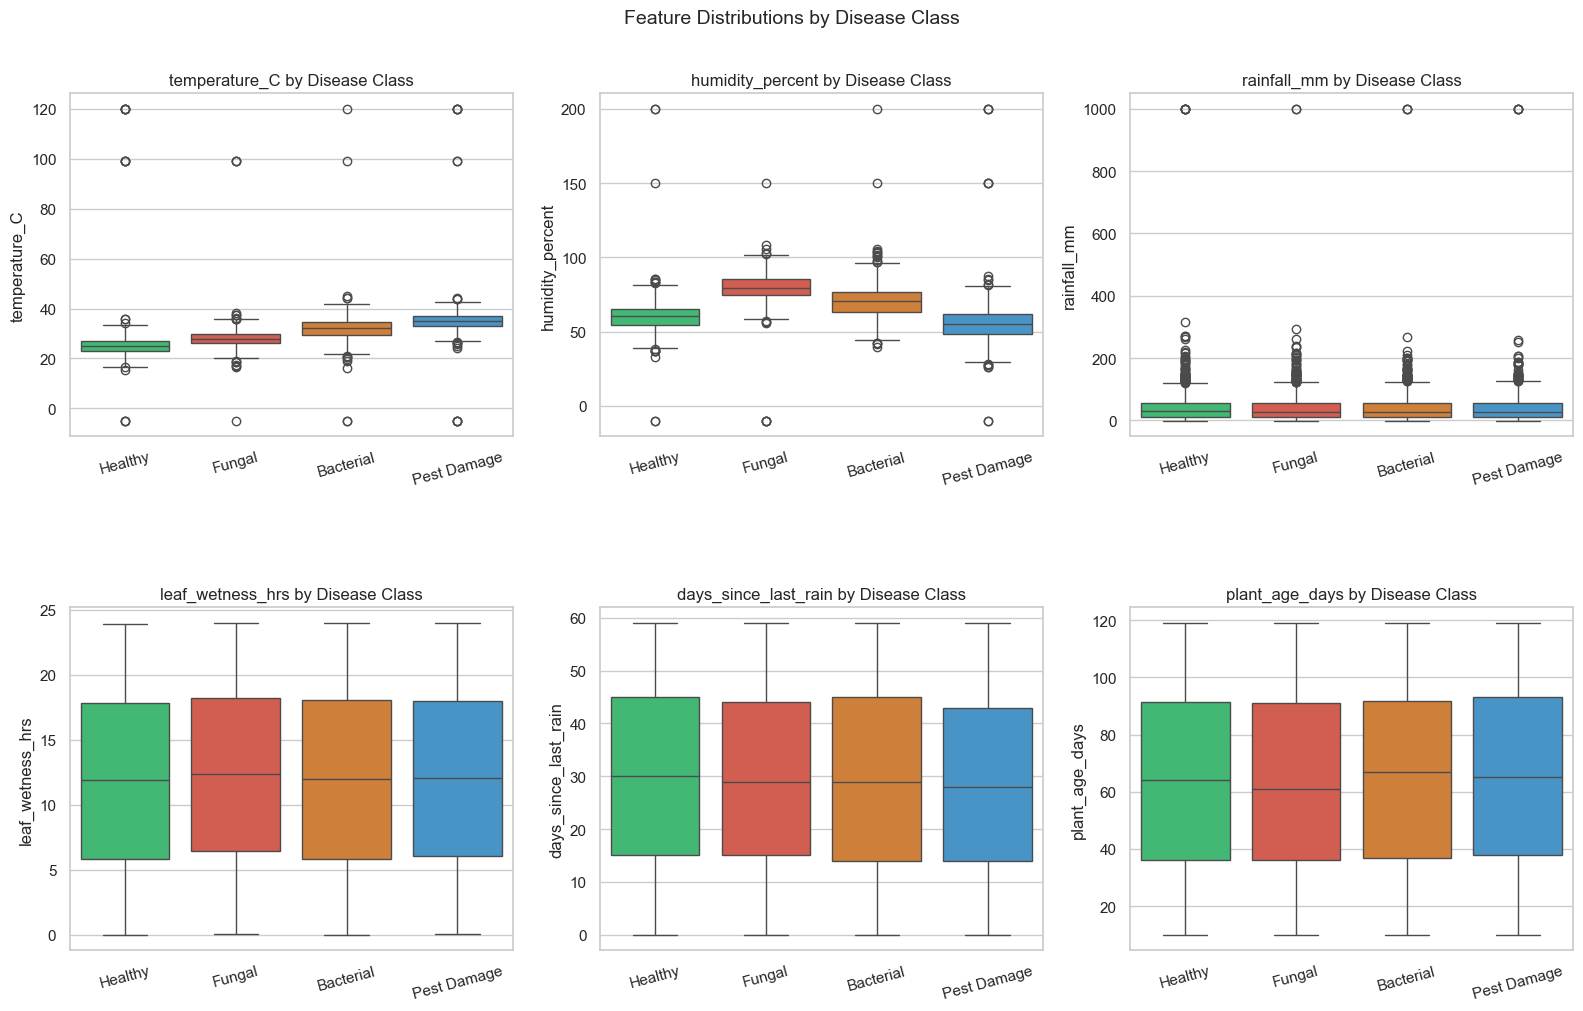

In [63]:

features_to_plot = ['temperature_C', 'humidity_percent', 'rainfall_mm', 'leaf_wetness_hrs', 'days_since_last_rain', 'plant_age_days']
palette = {'Healthy':'#2ecc71','Fungal':'#e74c3c','Bacterial':'#e67e22','Pest Damage':'#3498db'}
order_box = ['Healthy', 'Fungal', 'Bacterial', 'Pest Damage']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    sns.boxplot(x='disease_label', y=feat, data=cropdis, order=order_box,
                hue='disease_label', palette=palette, legend=False, ax=axes[i])
    axes[i].set_title(f'{feat} by Disease Class')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)


plt.suptitle('Feature Distributions by Disease Class', fontsize=14, y=1.01)
plt.tight_layout(h_pad=6)  # h_pad to increase the gap between two rows
plt.show()

#### Observations:

- `Humidity_Percent` is slightly higher for Fungal and Bacterial diseases, indicating it may influence disease occurrence.
- 'leaf_wetness_hrs`: Leaf wetness is generally higher for Fungal diseases, suggesting a possible relationship.
- `temperature_C`, `rainfall_mm`, `days_since_last_rain`, `plant_age_days` show considerable overlap across all disease classes.
- **No single feature clearly distinguishes the disease classes, indicating that the model should use multiple features together for accurate prediction.**

## Summary:
The **Exploratory Data Analysis** provides a clear understanding of the Dataset, including Missing Values, Outliers, Class Balance, Relationship between variables. Based on these findings let us focus on Data Cleaning (handling missing values, treating outliers etc) followed by Feature Engineering and data processing to prepare a dataset for Machine Learning model development. 